In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('athlete_events.csv')
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [5]:
data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [4]:
data.rename(columns={"ID"    : "id",
                     "Name"  : "isim",
                     "Sex"   : "cinsiyet",
                     "Age"   : "yas",
                     "Height": "boy",
                     "Weight": "kilo",
                     "Team"  : "takim",
                     "NOC"   : "uok",
                     "Games" : "oyunlar",
                     "Year"  : "yil",
                     "Season": "sezon",
                     "City"  : "sehir",
                     "Sport" : "spor",
                     "Event" : "etkinlik",
                     "Medal" : "madalya"}, inplace=True)

In [5]:
data.head(2)

,id,isim,cinsiyet,yas,boy,kilo,takim,uok,oyunlar,yil,sezon,sehir,spor,etkinlik,madalya
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN


In [6]:
data = data.drop(["id", "oyunlar"], axis=1) #axis=1 sütun anlamına gelir!!!

In [7]:
data.head(2)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
0,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   isim      271116 non-null  object 
 1   cinsiyet  271116 non-null  object 
 2   yas       261642 non-null  float64
 3   boy       210945 non-null  float64
 4   kilo      208241 non-null  float64
 5   takim     271116 non-null  object 
 6   uok       271116 non-null  object 
 7   yil       271116 non-null  int64  
 8   sezon     271116 non-null  object 
 9   sehir     271116 non-null  object 
 10  spor      271116 non-null  object 
 11  etkinlik  271116 non-null  object 
 12  madalya   39783 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 26.9+ MB


In [8]:
gecici_veri = data.copy()

# boy ve kiloyu etkinlik bazında gruplandırıp ortalamalarını alıyoruz
boy_grup_ort = gecici_veri.groupby("etkinlik")["boy"].transform("mean")
kilo_grup_ort = gecici_veri.groupby("etkinlik")["kilo"].transform("mean")


# tek bir kişiden oluşan gruplar içinde genel ortalama hesaplanır ki o boşluklar da genel ortalama ile doldurulur
genel_boy_ort = gecici_veri["boy"].mean()
genel_kilo_ort = gecici_veri["kilo"].mean()

# boş değerleri etkinlik ortalması ile eğer ortalama hesaplanmıyorsa genel ortalama ile dolduruyoruz
gecici_veri["boy"] = gecici_veri["boy"].fillna(boy_grup_ort).fillna(genel_boy_ort)
gecici_veri["kilo"] = gecici_veri["kilo"].fillna(kilo_grup_ort).fillna(genel_kilo_ort)

# yaş sütununun genel ortalması hesaplanır
yas_genel_ort = gecici_veri["yas"].mean()

# genel ortalama boş verilere doldurulur
gecici_veri["yas"] = gecici_veri["yas"].fillna(yas_genel_ort)

data = gecici_veri.copy()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   isim      271116 non-null  object 
 1   cinsiyet  271116 non-null  object 
 2   yas       271116 non-null  float64
 3   boy       271116 non-null  float64
 4   kilo      271116 non-null  float64
 5   takim     271116 non-null  object 
 6   uok       271116 non-null  object 
 7   yil       271116 non-null  int64  
 8   sezon     271116 non-null  object 
 9   sehir     271116 non-null  object 
 10  spor      271116 non-null  object 
 11  etkinlik  271116 non-null  object 
 12  madalya   39783 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 26.9+ MB


In [ ]:
madalya = data["madalya"]
pd.isnull(madalya).sum()

np.int64(231333)

In [12]:
madalya_filtrele = ~pd.isnull(madalya)


In [13]:
data = data[madalya_filtrele]
data.head(5)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
3,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,Juhamatti Tapio Aaltonen,M,28.0,184.000000,85.000000,Finland,FIN,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,Paavo Johannes Aaltonen,M,28.0,175.000000,64.000000,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39783 entries, 3 to 271103
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   isim      39783 non-null  object 
 1   cinsiyet  39783 non-null  object 
 2   yas       39783 non-null  float64
 3   boy       39783 non-null  float64
 4   kilo      39783 non-null  float64
 5   takim     39783 non-null  object 
 6   uok       39783 non-null  object 
 7   yil       39783 non-null  int64  
 8   sezon     39783 non-null  object 
 9   sehir     39783 non-null  object 
 10  spor      39783 non-null  object 
 11  etkinlik  39783 non-null  object 
 12  madalya   39783 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 4.2+ MB


In [15]:
data.to_csv("olimpiyatlar_temizlenmis.csv", index=False)

In [16]:
def plotHistogram(degisken):
    plt.figure()
    plt.hist(data[degisken], bins = 85, color="red")
    plt.xlabel(degisken)
    plt.ylabel("Frekans")
    plt.title(f"Veri Sıklığı - {degisken}")
    plt.show()

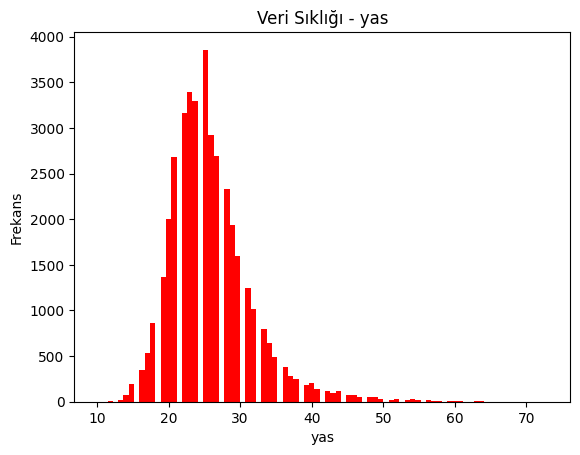

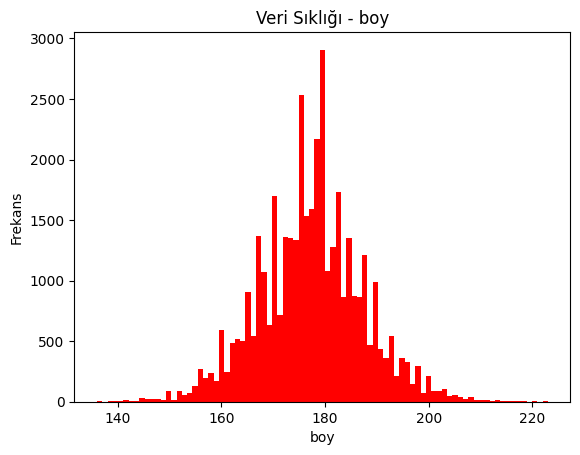

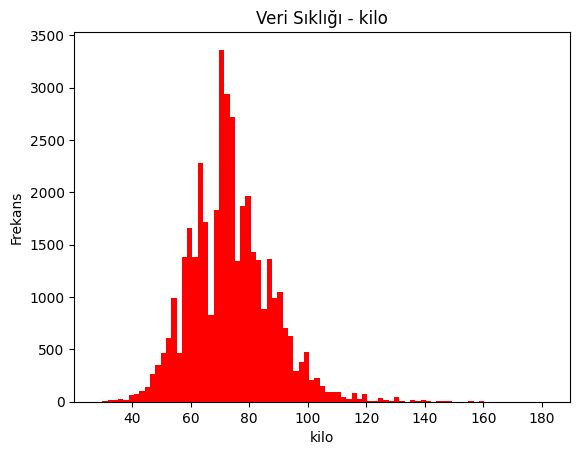

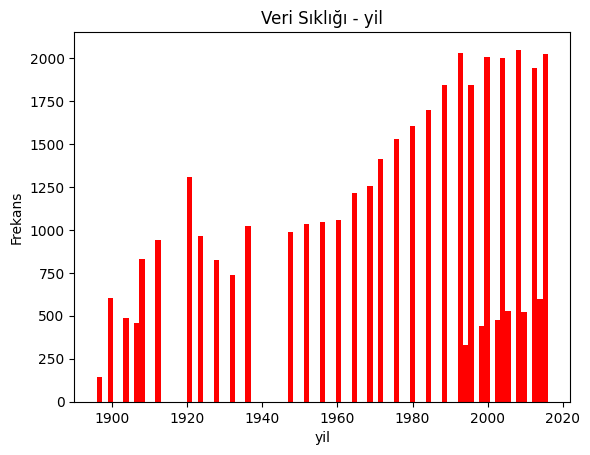

In [19]:
sayisal_degisken = ["yas", "boy", "kilo", "yil"]
for i in sayisal_degisken:
    plotHistogram(i)


In [20]:
data.describe()

,yas,boy,kilo,yil
count,39783.000000,39783.000000,39783.000000,39783.000000
mean,25.918399,177.336668,73.738385,1973.943845
std,5.859573,10.170201,13.978897,33.822857
min,10.000000,136.000000,28.000000,1896.000000
25%,22.000000,170.000000,64.000000,1952.000000
50%,25.000000,177.480339,73.000000,1984.000000
75%,29.000000,184.000000,82.000000,2002.000000
max,73.000000,223.000000,182.000000,2016.000000


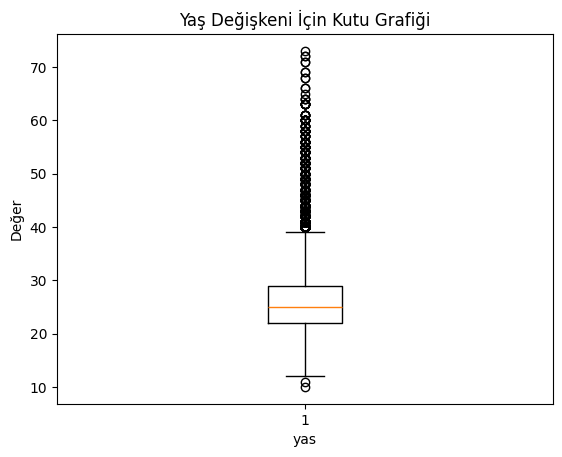

In [ ]:
# yaş için kutu grafiği
plt.boxplot(data.yas)
plt.title("Yaş Değişkeni İçin Kutu Grafiği")
plt.xlabel("yas")
plt.ylabel("Değer")
plt.show()


In [33]:
# çubuk grafikleri metodu
def plotBar(degisken, n = 5):
    data_ = data[degisken]
    data_count = data_.value_counts()
    data_count = data_count[:n]
    plt.figure()
    plt.bar(data_count.index, data_count, color="orange")
    plt.xticks(data_count.index, data_count.index.values)
    plt.xticks(rotation=45)
    plt.ylabel("Frekans")
    plt.title(f"Veri Sıklığı {degisken}")
    plt.show()
    print(f"{degisken}: \n {data_count}")



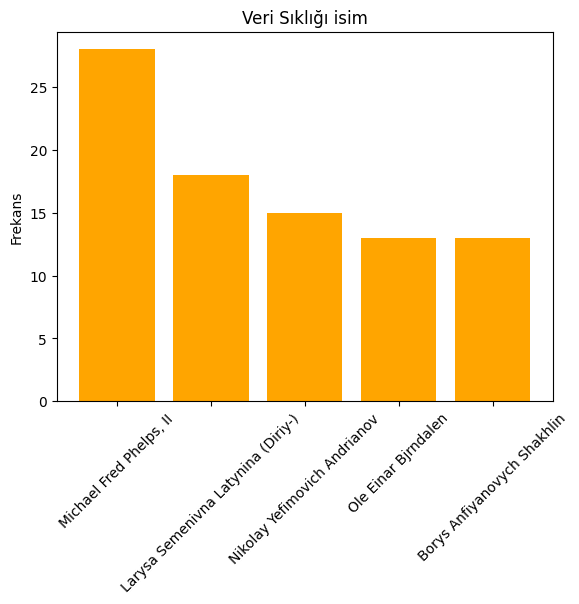

isim: 
 isim
Michael Fred Phelps, II               28
Larysa Semenivna Latynina (Diriy-)    18
Nikolay Yefimovich Andrianov          15
Ole Einar Bjrndalen                   13
Borys Anfiyanovych Shakhlin           13
Name: count, dtype: int64


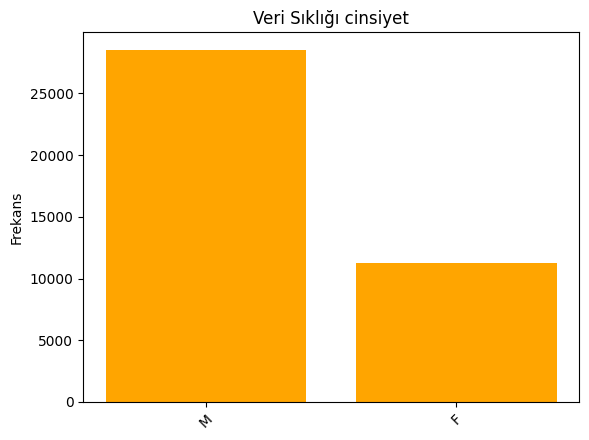

cinsiyet: 
 cinsiyet
M    28530
F    11253
Name: count, dtype: int64


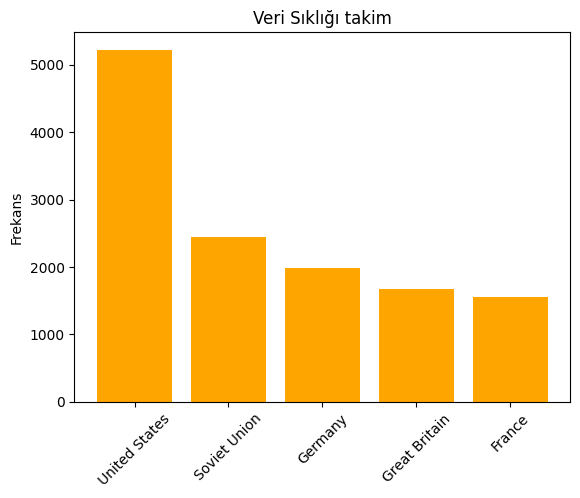

takim: 
 takim
United States    5219
Soviet Union     2451
Germany          1984
Great Britain    1673
France           1550
Name: count, dtype: int64


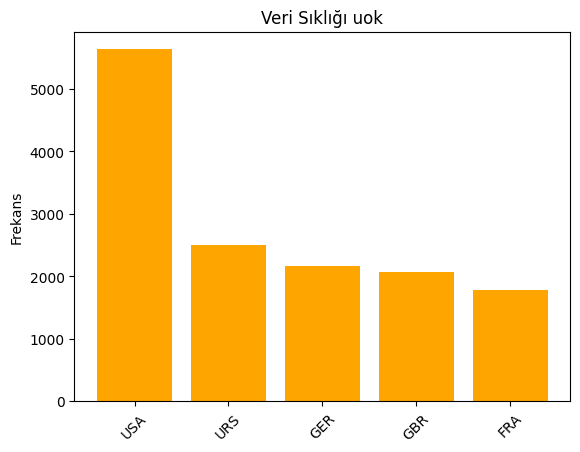

uok: 
 uok
USA    5637
URS    2503
GER    2165
GBR    2068
FRA    1777
Name: count, dtype: int64


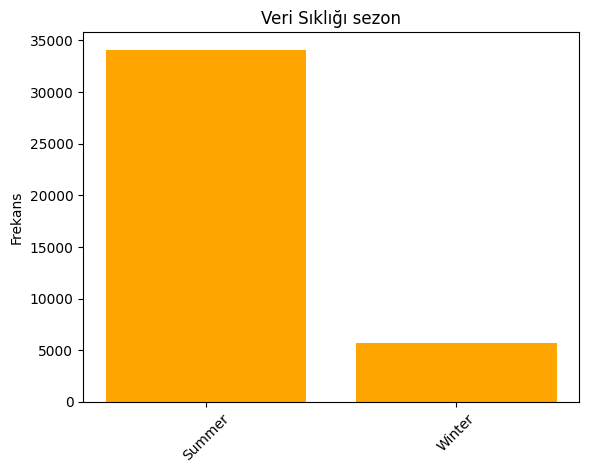

sezon: 
 sezon
Summer    34088
Winter     5695
Name: count, dtype: int64


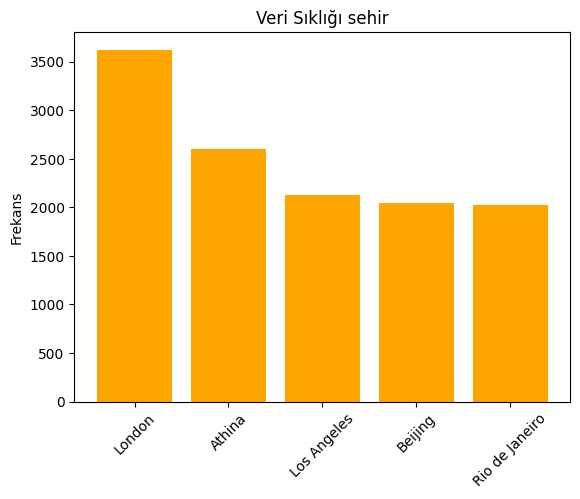

sehir: 
 sehir
London            3624
Athina            2602
Los Angeles       2123
Beijing           2048
Rio de Janeiro    2023
Name: count, dtype: int64


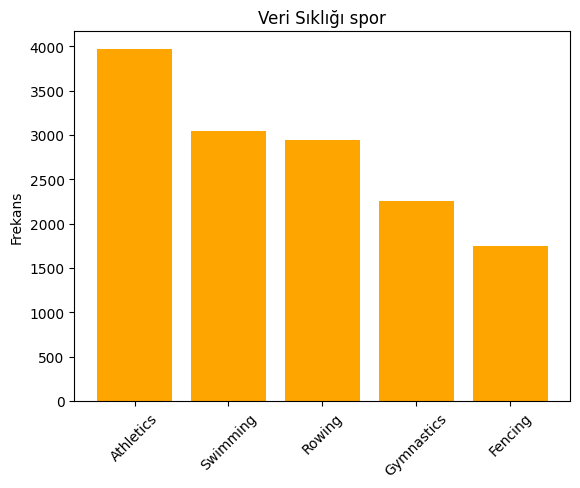

spor: 
 spor
Athletics     3969
Swimming      3048
Rowing        2945
Gymnastics    2256
Fencing       1743
Name: count, dtype: int64


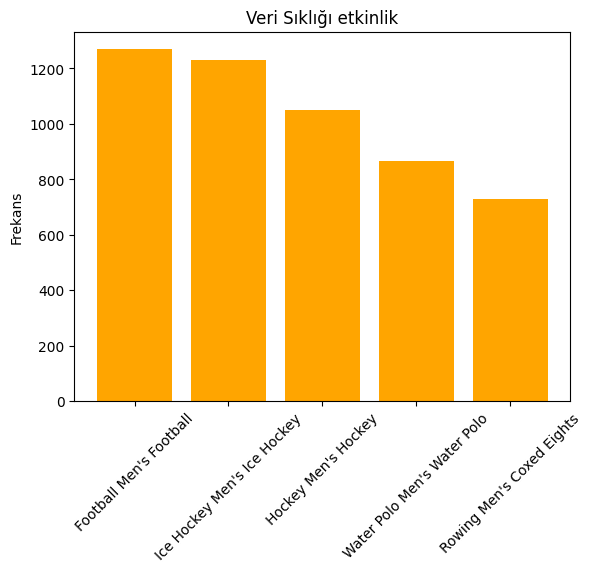

etkinlik: 
 etkinlik
Football Men's Football        1269
Ice Hockey Men's Ice Hockey    1230
Hockey Men's Hockey            1050
Water Polo Men's Water Polo     866
Rowing Men's Coxed Eights       730
Name: count, dtype: int64


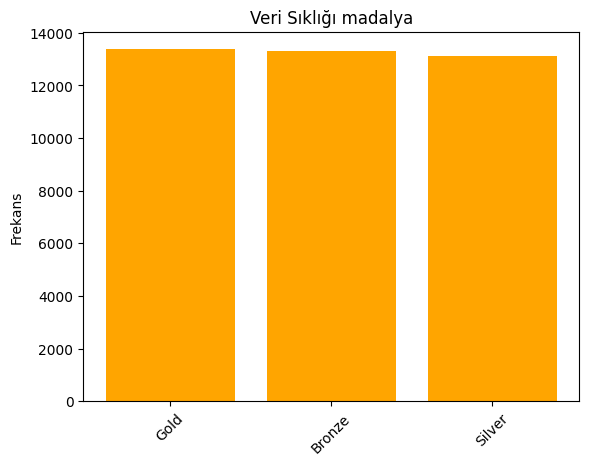

madalya: 
 madalya
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64


In [34]:
kategorik_degisken = ["isim", "cinsiyet", "takim", "uok", "sezon", "sehir", "spor", "etkinlik", "madalya"]
for i in kategorik_degisken:
    plotBar(i)

In [37]:
man = data[data.cinsiyet == "M"]
man.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
3,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze


In [41]:
woman = data[data["cinsiyet"] == "F"]
woman.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
79,Ragnhild Margrethe Aamodt,F,27.0,163.000000,68.876851,Norway,NOR,2008,Summer,Beijing,Handball,Handball Women's Handball,Gold
91,Willemien Aardenburg,F,22.0,166.125267,60.530935,Netherlands,NED,1988,Summer,Seoul,Hockey,Hockey Women's Hockey,Bronze
105,Ann Kristin Aarnes,F,23.0,182.000000,64.000000,Norway,NOR,1996,Summer,Atlanta,Football,Football Women's Football,Bronze


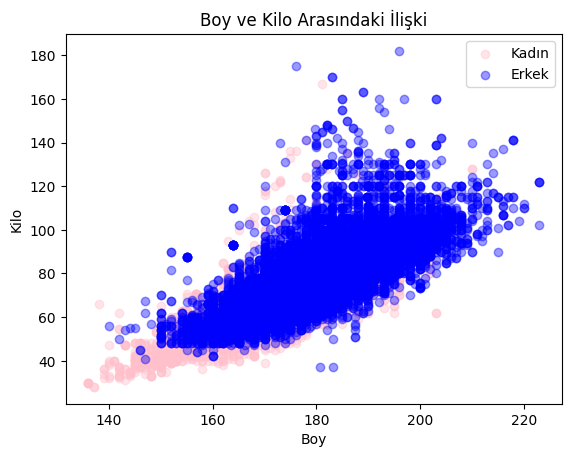

In [42]:
plt.figure()
plt.scatter(woman.boy, woman.kilo, alpha=0.4, label="Kadın", color="pink")
plt.scatter(man.boy, man.kilo, alpha=0.4, label="Erkek", color="blue")
plt.xlabel("Boy")
plt.ylabel("Kilo")
plt.title("Boy ve Kilo Arasındaki İlişki")
plt.legend()
plt.show()

In [43]:
data.loc[:,["yas", "boy", "kilo"]].corr()

,yas,boy,kilo
yas,1.000000,0.061879,0.136355
boy,0.061879,1.000000,0.794365
kilo,0.136355,0.794365,1.000000


In [45]:
# sporcularımızı altın, gümüş ve bronz madalyaya göre ayıralım
gecici_data = data.copy()
gecici_data = pd.get_dummies(gecici_data, columns=["madalya"])
gecici_data.head(2)


,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya_Bronze,madalya_Gold,madalya_Silver
3,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,False,True,False
37,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,True,False,False


In [48]:
gecici_data[["yas", "madalya_Bronze", "madalya_Gold", "madalya_Silver"]].corr()

,yas,madalya_Bronze,madalya_Gold,madalya_Silver
yas,1.000000,-0.005585,-0.002574,0.008191
madalya_Bronze,-0.005585,1.000000,-0.504110,-0.496859
madalya_Gold,-0.002574,-0.504110,1.000000,-0.499022
madalya_Silver,0.008191,-0.496859,-0.499022,1.000000


In [50]:
gecici_data[["takim", "madalya_Bronze", "madalya_Gold", "madalya_Silver"]].groupby(["takim"], as_index=False).sum().sort_values(by="madalya_Gold", ascending=False)[:10]

,takim,madalya_Bronze,madalya_Gold,madalya_Silver
462,United States,1233,2474,1512
403,Soviet Union,677,1058,716
165,Germany,678,679,627
215,Italy,484,535,508
171,Great Britain,572,519,582
149,France,577,455,518
420,Sweden,507,451,476
198,Hungary,365,432,330
67,Canada,408,422,413
117,East Germany,263,369,309


In [51]:
# en çok altın madalya alan ülkelere göre madalya kazananları listele
gecici_data[["takim", "madalya_Bronze", "madalya_Gold", "madalya_Silver"]].groupby(["takim"], as_index=False).sum().sort_values(by="madalya_Gold", ascending=False)[:10]

,takim,madalya_Bronze,madalya_Gold,madalya_Silver
462,United States,1233,2474,1512
403,Soviet Union,677,1058,716
165,Germany,678,679,627
215,Italy,484,535,508
171,Great Britain,572,519,582
149,France,577,455,518
420,Sweden,507,451,476
198,Hungary,365,432,330
67,Canada,408,422,413
117,East Germany,263,369,309


In [ ]:
gecici_data[["takim", "madalya_Bronze", "madalya_Gold", "madalya_Silver"]].groupby(["takim"], as_index=False).sum().sort_values(by="madalya_Gold", ascending=False)[:10]

In [52]:
gecici_data[["sehir", "madalya_Bronze", "madalya_Gold", "madalya_Silver"]].groupby(["sehir"], as_index=False).sum().sort_values(by="madalya_Gold", ascending=False)[:10]

,sehir,madalya_Bronze,madalya_Gold,madalya_Silver
17,London,1214,1215,1195
3,Athina,860,883,859
18,Los Angeles,706,726,691
6,Beijing,710,671,667
27,Rio de Janeiro,703,665,655
38,Sydney,680,663,661
4,Atlanta,629,608,605
5,Barcelona,604,559,549
33,Seoul,549,520,513
2,Antwerpen,367,493,448


In [94]:
# cinsiyet bazlı en çok madalya alan sıralaması
gecici_data.groupby("cinsiyet", as_index=False)[["madalya_Bronze", "madalya_Gold", "madalya_Silver"]].sum().nlargest(5,"madalya_Gold") 

,cinsiyet,madalya_Bronze,madalya_Gold,madalya_Silver
1,M,9524,9625,9381
0,F,3771,3747,3735


In [68]:
gecici_data.groupby("cinsiyet")[["madalya_Bronze", "madalya_Gold", "madalya_Silver"]].sum().sort_values("madalya_Gold", ascending=False)

,madalya_Bronze,madalya_Gold,madalya_Silver
cinsiyet,,,
M,9524,9625,9381
F,3771,3747,3735


In [77]:
data_pivot = data.pivot_table(index="madalya", columns="cinsiyet",
                              values=["boy","kilo", "yas"],
                              aggfunc={"boy":np.mean, "kilo":np.mean, "yas":[min, max, np.std]})
data_pivot.head()

boy                   kilo              yas              \
                mean                   mean              max         min   
cinsiyet           F           M          F          M     F     M     F   
madalya                                                                    
Bronze    170.003195  180.045822  62.757170  77.841534  69.0  72.0  12.0   
Gold      170.448688  180.318857  63.199376  78.186614  63.0  64.0  13.0   
Silver    170.233729  180.053616  62.866925  77.960978  55.0  73.0  11.0   

                                    
                     std            
cinsiyet     M         F         M  
madalya                             
Bronze    10.0  5.329228  5.870352  
Gold      13.0  5.219615  5.987814  
Silver    13.0  5.253110  6.098238

In [80]:
def anomaliTespiti(df, ozellik):
    outlier_indices = []

    for c in ozellik:
        Q1 = np.percentile(df[c],25)
        Q3 = np.percentile(df[c],75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)


    outlier_indices = Counter(outlier_indices)

    multiplie_outliers = list(i for i, v in outlier_indices.items() if v > 1)

    return multiplie_outliers

In [82]:
veri_anomali = data.loc[anomaliTespiti(data, ["yas", "kilo", "boy"])]
veri_anomali.spor.value_counts()

spor
Basketball        64
Gymnastics        34
Handball           6
Athletics          5
Sailing            3
Diving             3
Shooting           1
Figure Skating     1
Wrestling          1
Name: count, dtype: int64

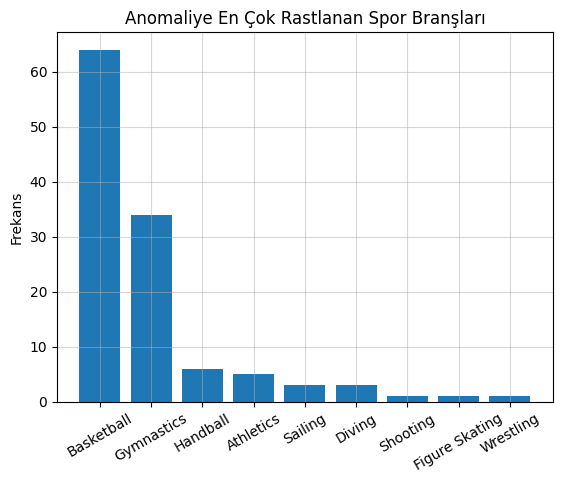

In [96]:
plt.figure()
plt.bar(veri_anomali.spor.value_counts().index, veri_anomali.spor.value_counts().values)
plt.xticks(rotation= 30)
plt.title("Anomaliye En Çok Rastlanan Spor Branşları")
plt.ylabel("Frekans")
plt.grid(True, alpha=0.5)
plt.show()

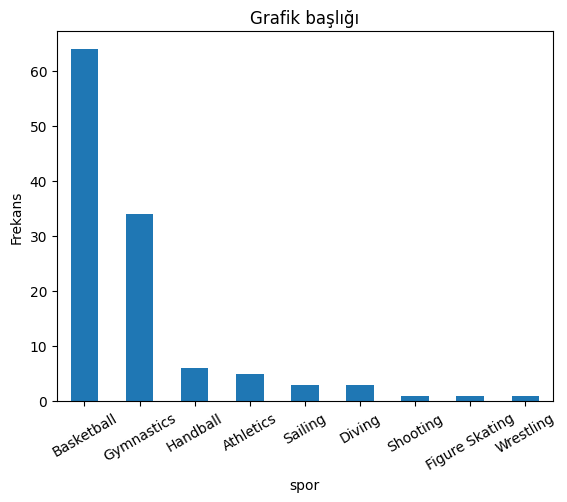

In [98]:
plt.figure()
veri_anomali.spor.value_counts().plot(kind="bar")
plt.xticks(rotation=30)
plt.title("Grafik başlığı")
plt.ylabel("Frekans")
plt.show()

In [99]:
veri_gym = veri_anomali[veri_anomali.spor == "Gymnastics"]
veri_gym

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
13741,Oana Mihaela Ban,F,18.0,139.0,36.0,Romania,ROU,2004,Summer,Athina,Gymnastics,Gymnastics Women's Team All-Around,Gold
21260,Bi Wenjing,F,14.0,142.0,35.0,China,CHN,1996,Summer,Atlanta,Gymnastics,Gymnastics Women's Uneven Bars,Silver
23763,Loredana Boboc,F,16.0,139.0,32.0,Romania,ROU,2000,Summer,Sydney,Gymnastics,Gymnastics Women's Team All-Around,Gold
47452,Laura Cutina,F,15.0,143.0,36.0,Romania,ROU,1984,Summer,Los Angeles,Gymnastics,Gymnastics Women's Team All-Around,Gold
53751,Deng Linlin,F,16.0,144.0,34.0,China,CHN,2008,Summer,Beijing,Gymnastics,Gymnastics Women's Team All-Around,Gold
53759,Deng Linlin,F,20.0,144.0,34.0,China,CHN,2012,Summer,London,Gymnastics,Gymnastics Women's Balance Beam,Gold
69216,Mariya Yevgenyevna Filatova (-Kurbatova),F,14.0,136.0,30.0,Soviet Union,URS,1976,Summer,Montreal,Gymnastics,Gymnastics Women's Team All-Around,Gold
69222,Mariya Yevgenyevna Filatova (-Kurbatova),F,19.0,136.0,30.0,Soviet Union,URS,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Team All-Around,Gold
69225,Mariya Yevgenyevna Filatova (-Kurbatova),F,19.0,136.0,30.0,Soviet Union,URS,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Uneven Bars,Bronze
80497,Maxi Gnauck,F,15.0,148.0,33.0,East Germany,GDR,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Individual All-Around,Silver


In [100]:
veri_gym.etkinlik.value_counts()

etkinlik
Gymnastics Women's Team All-Around          21
Gymnastics Women's Uneven Bars               6
Gymnastics Women's Balance Beam              3
Gymnastics Women's Floor Exercise            2
Gymnastics Women's Individual All-Around     1
Gymnastics Women's Horse Vault               1
Name: count, dtype: int64

In [102]:
veri_basketbol = veri_anomali[veri_anomali.spor == "Basketball"]
veri_basketbol

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
8834,Franjo Arapovi,M,23.0,211.0,120.0,Yugoslavia,YUG,1988,Summer,Seoul,Basketball,Basketball Men's Basketball,Silver
8835,Franjo Arapovi,M,27.0,211.0,120.0,Croatia,CRO,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,Silver
21577,Oleksandr Mykhailovych Bielostienniy,M,21.0,214.0,117.0,Soviet Union,URS,1980,Summer,Moskva,Basketball,Basketball Men's Basketball,Bronze
21578,Oleksandr Mykhailovych Bielostienniy,M,29.0,214.0,117.0,Soviet Union,URS,1988,Summer,Seoul,Basketball,Basketball Men's Basketball,Gold
25598,"Carlos Austin Boozer, Jr.",M,22.0,206.0,117.0,United States,USA,2004,Summer,Athina,Basketball,Basketball Men's Basketball,Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
270119,Rajko ii,M,21.0,210.0,110.0,Yugoslavia,YUG,1976,Summer,Montreal,Basketball,Basketball Men's Basketball,Silver
270120,Rajko ii,M,25.0,210.0,110.0,Yugoslavia,YUG,1980,Summer,Moskva,Basketball,Basketball Men's Basketball,Gold
270121,Rajko ii,M,29.0,210.0,110.0,Yugoslavia,YUG,1984,Summer,Los Angeles,Basketball,Basketball Men's Basketball,Bronze
270740,Eurelijus ukauskas,M,22.0,218.0,115.0,Lithuania,LTU,1996,Summer,Atlanta,Basketball,Basketball Men's Basketball,Bronze


In [103]:
veri_basketbol.etkinlik.value_counts()

etkinlik
Basketball Men's Basketball      62
Basketball Women's Basketball     2
Name: count, dtype: int64

In [104]:
data_time = data.copy()
data_time.head(4)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya
3,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,Juhamatti Tapio Aaltonen,M,28.0,184.000000,85.000000,Finland,FIN,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze


In [105]:
essiz_yillar = data_time.yil.unique()
essiz_yillar

array([1900, 1920, 2014, 1948, 1952, 1992, 1994, 2002, 2006, 2008, 1988,
       1996, 1960, 1912, 1956, 2016, 2012, 2000, 2004, 1980, 1984, 1936,
       1906, 1964, 1972, 1924, 1904, 1932, 1928, 1968, 1976, 2010, 1908,
       1998, 1896])

In [ ]:
# burada numpy ile yılları eşsiz olarak sıralıyoruz
sirali_array = np.sort(data_time.yil.unique())
sirali_array

array([1896, 1900, 1904, 1906, 1908, 1912, 1920, 1924, 1928, 1932, 1936,
       1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988,
       1992, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012,
       2014, 2016])

In [109]:
# aynı sıralamayı numpy olmadan bu şekilde yapabiliriz
arrayiki = data_time.yil.sort_values().unique()
arrayiki

array([1896, 1900, 1904, 1906, 1908, 1912, 1920, 1924, 1928, 1932, 1936,
       1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988,
       1992, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012,
       2014, 2016])

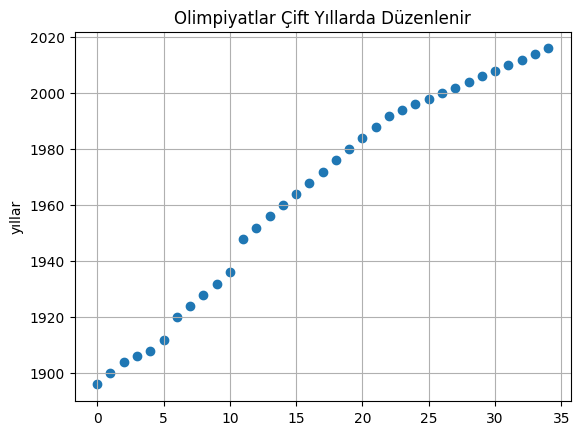

In [110]:
plt.figure()
plt.scatter(range(len(sirali_array)), sirali_array)
plt.grid(True)
plt.ylabel("yıllar")
plt.title("Olimpiyatlar Çift Yıllarda Düzenlenir")
plt.show()

In [111]:
tarih_saat_nesnesi = pd.to_datetime(data_time["yil"], format = '%Y')
print(type(tarih_saat_nesnesi))
tarih_saat_nesnesi.head(3)

<class 'pandas.core.series.Series'>


3    1900-01-01
37   1920-01-01
38   1920-01-01
Name: yil, dtype: datetime64[ns]

In [112]:
data_time["tarih_saat"] = tarih_saat_nesnesi
data_time.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,uok,yil,sezon,sehir,spor,etkinlik,madalya,tarih_saat
3,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900-01-01
37,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,1920-01-01
38,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,1920-01-01


In [115]:
data_time = data_time.set_index("tarih_saat")
data_time.drop(["yil"], axis =1, inplace=True)


KeyError: "None of ['tarih_saat'] are in the columns"

In [116]:
data_time.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,uok,sezon,sehir,spor,etkinlik,madalya
tarih_saat,,,,,,,,,,,,
1900-01-01,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
1920-01-01,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
1920-01-01,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze


In [119]:
# 2 yıllık periyotlar halinde ortalama alma
periyodik_veri = data_time.resample("2A").mean(numeric_only=True)
periyodik_veri.head()

,yas,boy,kilo
tarih_saat,,,
1896-12-31,23.904823,174.279714,72.734489
1898-12-31,NaN,NaN,NaN
1900-12-31,27.785990,177.882054,74.980433
1902-12-31,NaN,NaN,NaN
1904-12-31,26.363460,177.241663,74.331026


In [122]:
print(data_time.index.dtype)

datetime64[ns]


In [123]:
periyodik_veri.dropna(axis=0, inplace=True)
periyodik_veri.head()


,yas,boy,kilo
tarih_saat,,,
1896-12-31,23.904823,174.279714,72.734489
1900-12-31,27.785990,177.882054,74.980433
1904-12-31,26.363460,177.241663,74.331026
1906-12-31,26.478366,176.347347,74.072752
1908-12-31,27.566493,176.662395,73.722140


<Figure size 640x480 with 0 Axes>

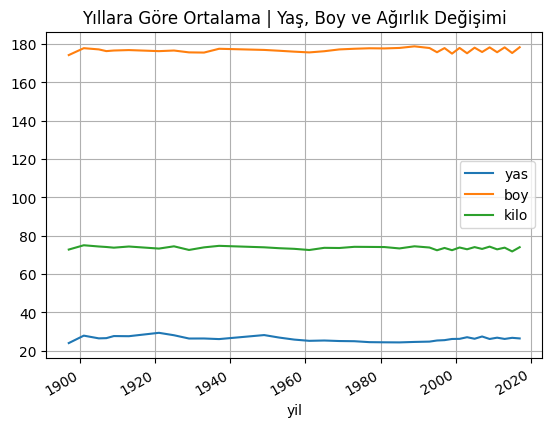

In [125]:
plt.figure()
periyodik_veri.plot()
plt.title("Yıllara Göre Ortalama | Yaş, Boy ve Ağırlık Değişimi")
plt.xlabel("yil")
plt.grid(True)
plt.show()

In [134]:
data_time = pd.get_dummies(data_time, columns=['madalya'])
data_time.head()

,isim,cinsiyet,yas,boy,kilo,takim,uok,sezon,sehir,spor,etkinlik,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,,,,,,,,,
1900-01-01,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,False,True,False
1920-01-01,Arvo Ossian Aaltonen,M,30.0,182.008432,76.694056,Finland,FIN,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,True,False,False
1920-01-01,Arvo Ossian Aaltonen,M,30.0,177.000000,75.000000,Finland,FIN,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,True,False,False
2014-01-01,Juhamatti Tapio Aaltonen,M,28.0,184.000000,85.000000,Finland,FIN,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,True,False,False
1948-01-01,Paavo Johannes Aaltonen,M,28.0,175.000000,64.000000,Finland,FIN,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,True,False,False


In [138]:
periyodik_veri = data_time.resample("2A").sum(numeric_only=True)
periyodik_veri.head()
periyodik_veri = periyodik_veri[(periyodik_veri != 0).any(axis=1)]
periyodik_veri.tail()

,yas,boy,kilo,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,
2008-12-31,53344.0,365157.901788,152090.906548,710,671,667
2010-12-31,13896.0,91395.000000,37877.108056,171,174,175
2012-12-31,50595.0,346091.472747,143102.949902,679,632,630
2014-12-31,15907.0,104686.000000,42838.618252,198,202,197
2016-12-31,53256.0,360846.028644,149628.695351,703,665,655


In [139]:
periyodik_veri.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35 entries, 1896-12-31 to 2016-12-31
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   yas             35 non-null     float64
 1   boy             35 non-null     float64
 2   kilo            35 non-null     float64
 3   madalya_Bronze  35 non-null     int64  
 4   madalya_Gold    35 non-null     int64  
 5   madalya_Silver  35 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 1.9 KB


<Figure size 640x480 with 0 Axes>

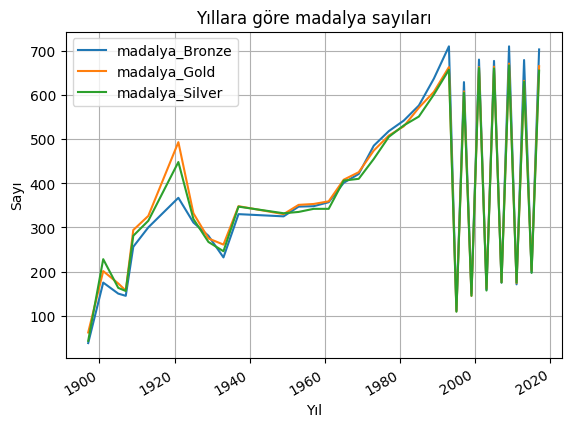

In [142]:
plt.figure()
periyodik_veri.loc[:,["madalya_Bronze", "madalya_Gold", "madalya_Silver"]].plot()
plt.title("Yıllara göre madalya sayıları")
plt.ylabel("Sayı")
plt.xlabel("Yıl")
plt.grid(True)
plt.show()

In [143]:
yaz = data_time[data_time.sezon == "Summer"]
kis = data_time[data_time.sezon == "Winter"]
kis.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,uok,sezon,sehir,spor,etkinlik,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,,,,,,,,,
2014-01-01,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,True,False,False
1992-01-01,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Super G,False,True,False
1992-01-01,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Giant Slalom,True,False,False


In [145]:
periyodik_veri_kis = kis.resample("A").sum(numeric_only=True)
periyodik_veri_kis = periyodik_veri_kis[(periyodik_veri_kis != 0).any(axis=1)]
periyodik_veri_kis.head()

,yas,boy,kilo,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,
1924-12-31,3919.568984,22867.226463,9703.522178,37,55,38
1928-12-31,2265.556898,15745.772313,6862.363009,31,30,28
1932-12-31,2431.000000,16357.709341,7067.617336,28,32,32
1936-12-31,2742.000000,19123.165876,8101.798371,35,36,37
1948-12-31,3643.000000,23942.498314,10375.717377,46,41,48


In [146]:
periyodik_veri_yaz = yaz.resample("A").sum(numeric_only=True)
periyodik_veri_yaz = periyodik_veri_yaz[(periyodik_veri_yaz != 0).any(axis=1)]
periyodik_veri_yaz.head()

,yas,boy,kilo,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,
1896-12-31,3418.389731,24921.999159,10401.031995,38,62,43
1900-12-31,16782.738177,107440.760337,45288.181268,175,201,228
1904-12-31,12812.641495,86139.448208,36124.878850,150,173,163
1906-12-31,12127.091652,80767.084943,33925.320248,145,157,156
1908-12-31,22907.755292,146806.450473,61263.098628,256,294,281


<Figure size 640x480 with 0 Axes>

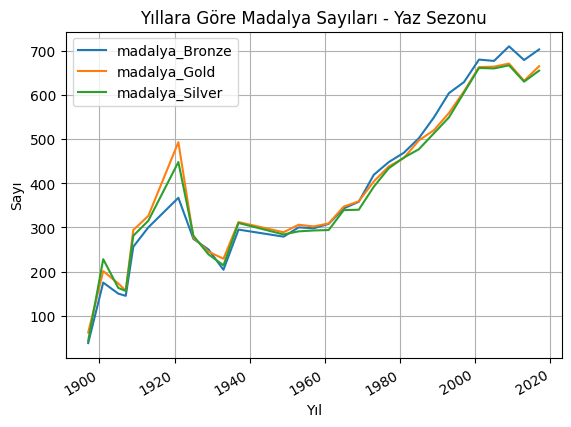

In [149]:
plt.figure()
periyodik_veri_yaz.loc[:,["madalya_Bronze", "madalya_Gold", "madalya_Silver"]].plot()
plt.title("Yıllara Göre Madalya Sayıları - Yaz Sezonu")
plt.ylabel("Sayı")
plt.xlabel("Yıl")
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

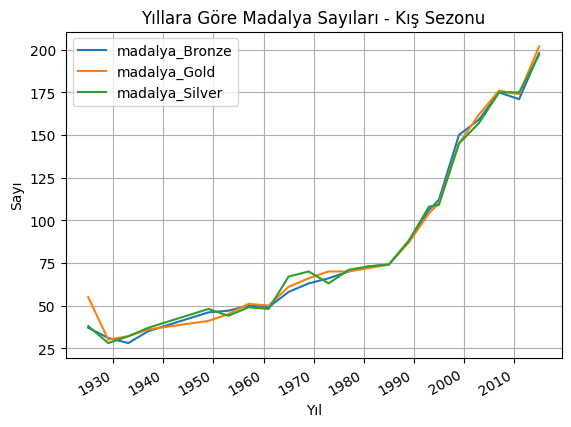

In [148]:
plt.figure()
periyodik_veri_kis.loc[:,["madalya_Bronze", "madalya_Gold", "madalya_Silver"]].plot()
plt.title("Yıllara Göre Madalya Sayıları - Kış Sezonu")
plt.ylabel("Sayı")
plt.xlabel("Yıl")
plt.grid(True)
plt.show()

In [159]:
er = data_time[data_time["cinsiyet"] == "F"]
er.head(5)

,isim,cinsiyet,yas,boy,kilo,takim,uok,sezon,sehir,spor,etkinlik,madalya_Bronze,madalya_Gold,madalya_Silver
tarih_saat,,,,,,,,,,,,,,
2008-01-01,Ragnhild Margrethe Aamodt,F,27.0,163.000000,68.876851,Norway,NOR,Summer,Beijing,Handball,Handball Women's Handball,False,True,False
1988-01-01,Willemien Aardenburg,F,22.0,166.125267,60.530935,Netherlands,NED,Summer,Seoul,Hockey,Hockey Women's Hockey,True,False,False
1996-01-01,Ann Kristin Aarnes,F,23.0,182.000000,64.000000,Norway,NOR,Summer,Atlanta,Football,Football Women's Football,True,False,False
2016-01-01,Patimat Abakarova,F,21.0,165.000000,49.000000,Azerbaijan,AZE,Summer,Rio de Janeiro,Taekwondo,Taekwondo Women's Flyweight,True,False,False
2008-01-01,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.000000,80.000000,Russia,RUS,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,False,False,True


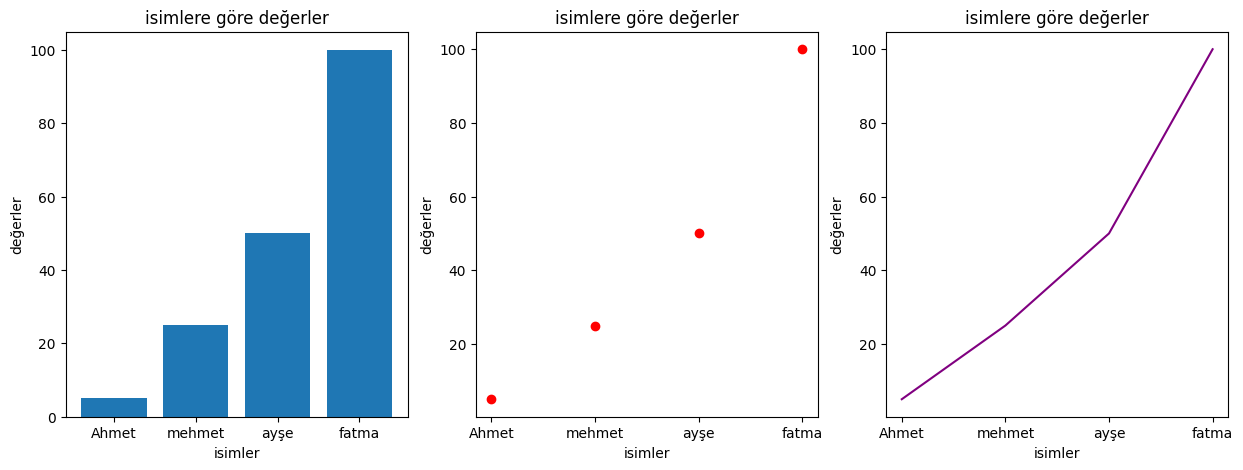

In [174]:
isimler = ["Ahmet", "mehmet", "ayşe", "fatma"]
degerler = [5, 25, 50, 100]

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.bar(isimler, degerler)
plt.title("isimlere göre değerler")
plt.ylabel("değerler")
plt.xlabel("isimler")

plt.subplot(132)
plt.scatter(isimler, degerler, color="red")
plt.title("isimlere göre değerler")
plt.ylabel("değerler")
plt.xlabel("isimler")

plt.subplot(133)
plt.plot(isimler, degerler, color="purple")
plt.title("isimlere göre değerler")
plt.ylabel("değerler")
plt.xlabel("isimler")

plt.show()